# 策略 1：红利低波月调组合

按月末信号、下一交易日生效的口径复刻红利低波月调组合，并与中证红利低波全收益指数比较。请先按需运行 `download.ipynb`。

In [1]:
import os
import sys
from pathlib import Path

project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from pyquant import calc_metrics, load_config, load_dataset
from strategies.dividend_low_vol.components import calculate_dividend_low_vol_monthly_rebalanced_index

plt.rcParams['font.family'] = 'STHeiti'
plt.rcParams['axes.unicode_minus'] = False

## 配置与本地数据

In [3]:
strategy_dir = project_root / 'strategies/dividend_low_vol'
config = load_config(strategy_dir / 'config.yaml')
start_date = pd.Timestamp(config['data']['start_date'])
end_date = pd.Timestamp(config['data']['end_date'])
lookback_date = start_date - pd.DateOffset(years=3)

price = load_dataset('stock_daily', start=lookback_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
dividends = load_dataset('dividend')
dividend_queries = load_dataset('dividend_queries')
shares = load_dataset('stock_profit_quarterly')
benchmark = load_dataset(
    'csindex_daily',
    start=start_date.strftime('%Y-%m-%d'),
    end=end_date.strftime('%Y-%m-%d'),
    symbols=['H20269'],
).set_index('date')['close'].rename('红利低波全收益指数')

## 月度调仓回测

In [4]:
strategy_index, constituents = calculate_dividend_low_vol_monthly_rebalanced_index(
    price,
    dividends,
    dividend_queries,
    shares,
    start_date,
    end_date,
    config,
)
returns = pd.concat(
    [
        strategy_index['total_return'].rename('红利低波月调组合'),
        benchmark.pct_change(fill_method=None),
    ],
    axis=1,
).dropna()
nav = (1 + returns).cumprod()

## 收益曲线

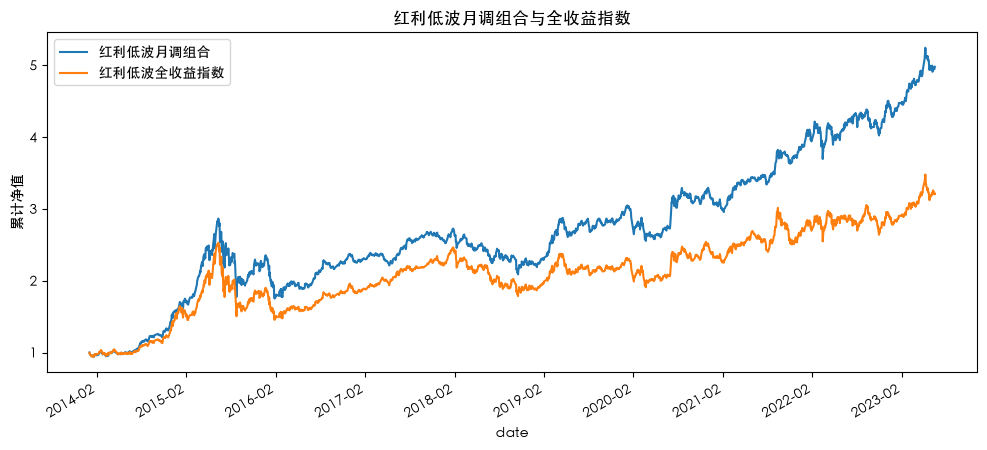

In [5]:
ax = nav.plot(figsize=(12, 5), title='红利低波月调组合与全收益指数')
ax.set_ylabel('累计净值')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.figure.autofmt_xdate()
plt.show()

## 绩效对比

信息比率按研报表格口径计算为年化收益除以年化波动；月度胜率为月末净值收益大于零的比例。

In [6]:
def summarize_performance(daily_returns):
    metrics = calc_metrics(daily_returns)
    monthly_returns = (1 + daily_returns).cumprod().resample('ME').last().pct_change().dropna()
    return pd.Series(
        {
            '年化收益': metrics['annual_return'],
            '年化波动': metrics['annual_vol'],
            '信息比率': metrics['sharpe'],
            '月度胜率': (monthly_returns > 0).mean(),
            '最大回撤': metrics['max_drawdown'],
        }
    )

performance = returns.apply(summarize_performance).T
performance.style.format({
    '年化收益': '{:.2%}',
    '年化波动': '{:.2%}',
    '信息比率': '{:.2f}',
    '月度胜率': '{:.2%}',
    '最大回撤': '{:.2%}',
})

,年化收益,年化波动,信息比率,月度胜率,最大回撤
红利低波月调组合,19.21%,19.42%,0.99,66.37%,-38.87%
红利低波全收益指数,13.61%,21.09%,0.65,62.83%,-42.49%
